# Cuboid Line Detection using Sequential RANSAC
Detects structural lines of a hand-drawn cuboid from an image using a Sequential RANSAC approach on edge pixels.

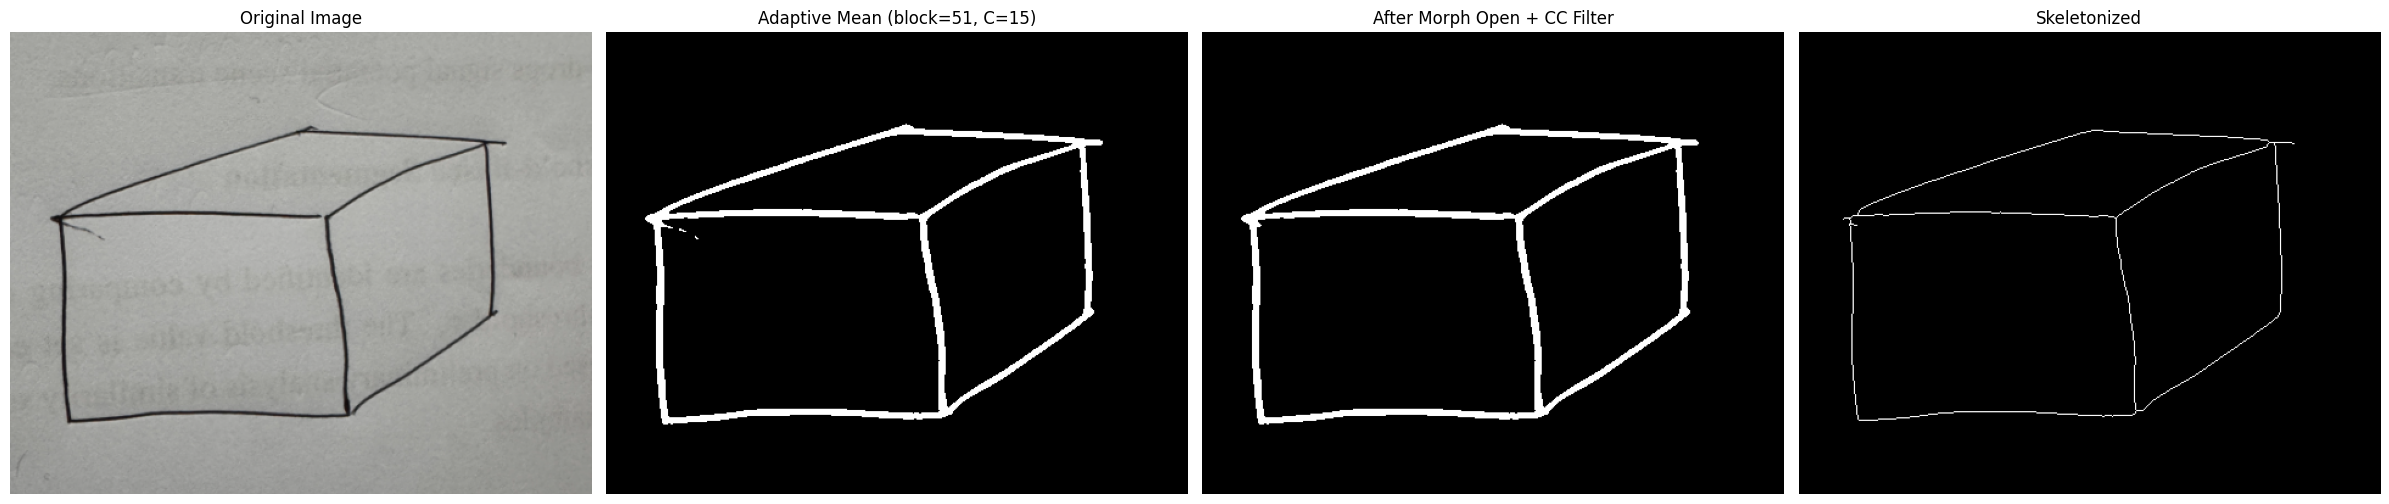

In [28]:
# Cell 1: Setup and Preprocessing
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import ransac, LineModelND
from skimage.morphology import skeletonize

# Load the image
img_color = cv2.imread('cuboid.png')
if img_color is None:
    raise FileNotFoundError("Could not load 'cuboid.png'. Make sure it is in the same directory as this notebook.")

# Convert BGR to RGB for matplotlib display
img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur to reduce paper texture
blurred = cv2.GaussianBlur(gray, (5, 5), 1.5)

# Adaptive Mean threshold: compares each pixel to the mean of its local
# neighborhood, so it handles uneven lighting and ignores faint bleed-through.
# blockSize: size of the local neighborhood (must be odd). Increase for broader context.
# C: constant subtracted from the local mean. Increase to require darker strokes.
adaptive_block = 51
adaptive_C = 15
binary = cv2.adaptiveThreshold(
    blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY_INV, adaptive_block, adaptive_C
)

# Light morphological opening to remove small specks without eroding thin lines
# Use a small 3x3 kernel with 1 iteration — increase if noise remains
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
binary_clean = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

# Remove small connected components — keep only large blobs (cuboid strokes)
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_clean, connectivity=8)
min_component_area = 200  # pixels; increase to be more aggressive
filtered = np.zeros_like(binary_clean)
for lbl in range(1, num_labels):
    if stats[lbl, cv2.CC_STAT_AREA] >= min_component_area:
        filtered[labels == lbl] = 255

# Skeletonize from the cleaned binary to get 1-pixel-wide lines
skeleton = skeletonize(filtered > 0)
edges = (skeleton.astype(np.uint8)) * 255

# Plot original, adaptive binarized, cleaned binary, and skeleton
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
axes[0].imshow(img_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(binary, cmap='gray')
axes[1].set_title(f'Adaptive Mean (block={adaptive_block}, C={adaptive_C})')
axes[1].axis('off')

axes[2].imshow(filtered, cmap='gray')
axes[2].set_title('After Morph Open + CC Filter')
axes[2].axis('off')

axes[3].imshow(edges, cmap='gray')
axes[3].set_title('Skeletonized')
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [29]:
# Cell 2: Extracting Pixel Coordinates

# np.nonzero returns (row_indices, col_indices) i.e. (y, x)
ys, xs = np.nonzero(edges)

# Stack into an Nx2 array of (x, y) points for RANSAC
points = np.column_stack((xs, ys)).astype(np.float64)

print(f'Total edge pixels extracted: {len(points)}')

Total edge pixels extracted: 1528


In [34]:
# Cell 3: The Sequential RANSAC Loop

detected_lines = []          # Will store (x0, y0, x1, y1) for each detected segment
remaining_points = points.copy()

min_points_to_continue = 50  # Stop if fewer edge pixels remain
max_lines = 15               # Maximum number of lines to extract
min_inliers = 30             # Minimum inliers to accept a line (skip noise)

# RANSAC residual_threshold: how far (in pixels) a point can be from
# the fitted line and still count as an inlier.
# Since the skeleton is 1-pixel wide, use a very tight threshold (1.0-1.5)
# to prevent the line from "absorbing" nearby perpendicular/intersecting pixels.
residual_threshold = 1.0

# Max gap allowed between consecutive inlier pixels along the line.
# If a gap exceeds this, only the largest continuous chunk is kept.
max_gap = 15

for i in range(max_lines):
    if len(remaining_points) < min_points_to_continue:
        print(f'Stopping: only {len(remaining_points)} points remain (< {min_points_to_continue}).')
        break

    # Run RANSAC with LineModelND
    model, inlier_mask = ransac(
        remaining_points,
        LineModelND,
        min_samples=2,
        residual_threshold=residual_threshold,
        max_trials=1000,
    )

    inlier_points = remaining_points[inlier_mask]
    num_inliers = len(inlier_points)

    if num_inliers < min_inliers:
        print(f'Stopping at iteration {i}: only {num_inliers} inliers (< {min_inliers}), likely noise.')
        break

    # --- Gap detection: keep only the largest continuous chunk ---

    # Determine line orientation: horizontal vs vertical
    x_range = inlier_points[:, 0].max() - inlier_points[:, 0].min()
    y_range = inlier_points[:, 1].max() - inlier_points[:, 1].min()

    # Sort by dominant axis
    if x_range >= y_range:
        sort_idx = np.argsort(inlier_points[:, 0])  # horizontal: sort by X
    else:
        sort_idx = np.argsort(inlier_points[:, 1])  # vertical: sort by Y

    sorted_pts = inlier_points[sort_idx]

    # Calculate distances between consecutive sorted points
    diffs = np.linalg.norm(np.diff(sorted_pts, axis=0), axis=1)

    # Find gap positions where distance exceeds max_gap
    gap_positions = np.where(diffs > max_gap)[0]

    # Split into chunks at gap positions
    split_indices = np.concatenate(([0], gap_positions + 1, [len(sorted_pts)]))
    chunks = []
    for j in range(len(split_indices) - 1):
        start = split_indices[j]
        end = split_indices[j + 1]
        chunks.append(sorted_pts[start:end])

    # Keep only the largest continuous chunk
    best_chunk = max(chunks, key=len)

    if len(best_chunk) < min_inliers:
        print(f'Stopping at iteration {i}: largest chunk only {len(best_chunk)} pts (< {min_inliers}).')
        break

    # --- Calculate endpoints from the best chunk ---
    origin = model.origin
    direction = model.direction

    projections = (best_chunk - origin) @ direction
    t_min = projections.min()
    t_max = projections.max()

    p_start = origin + t_min * direction
    p_end = origin + t_max * direction

    x0, y0 = p_start
    x1, y1 = p_end

    detected_lines.append((x0, y0, x1, y1))
    print(f'Line {i+1}: ({x0:.0f}, {y0:.0f}) -> ({x1:.0f}, {y1:.0f})  |  inliers: {num_inliers} -> chunk: {len(best_chunk)}')

    # CRUCIAL: Remove ALL inlier points (not just the chunk) so the next
    # iteration is forced to find a different line
    remaining_points = remaining_points[~inlier_mask]

print(f'\nTotal lines detected: {len(detected_lines)}')
print(f'Remaining unassigned points: {len(remaining_points)}')

Line 1: (232, 82) -> (61, 139)  |  inliers: 165 -> chunk: 165
Line 2: (236, 81) -> (384, 88)  |  inliers: 149 -> chunk: 149
Line 3: (158, 150) -> (264, 150)  |  inliers: 151 -> chunk: 90
Line 4: (43, 152) -> (44, 297)  |  inliers: 145 -> chunk: 145
Line 5: (127, 311) -> (273, 315)  |  inliers: 135 -> chunk: 133
Line 6: (391, 91) -> (397, 215)  |  inliers: 124 -> chunk: 124
Line 7: (258, 152) -> (277, 269)  |  inliers: 104 -> chunk: 102
Line 8: (393, 236) -> (274, 314)  |  inliers: 97 -> chunk: 97
Line 9: (126, 313) -> (49, 320)  |  inliers: 81 -> chunk: 78
Line 10: (395, 90) -> (319, 116)  |  inliers: 71 -> chunk: 71
Line 11: (165, 147) -> (124, 149)  |  inliers: 66 -> chunk: 35
Line 12: (319, 116) -> (256, 153)  |  inliers: 51 -> chunk: 51
Line 13: (276, 312) -> (274, 266)  |  inliers: 41 -> chunk: 38
Stopping at iteration 13: only 22 inliers (< 30), likely noise.

Total lines detected: 13
Remaining unassigned points: 148


In [36]:
# Cell 4: Post-Processing - Corner Snapping
import copy
from itertools import combinations

def line_intersection(line1, line2):
    """Calculate the intersection point of two infinite lines defined by segments.
    Each line is (x0, y0, x1, y1).
    Returns (x, y) or None if lines are parallel."""
    x1, y1, x2, y2 = line1
    x3, y3, x4, y4 = line2

    denom = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if abs(denom) < 1e-10:
        return None  # parallel or coincident

    t = ((x1 - x3) * (y3 - y4) - (y1 - y3) * (x3 - x4)) / denom

    ix = x1 + t * (x2 - x1)
    iy = y1 + t * (y2 - y1)
    return (ix, iy)

# Distance threshold: endpoints closer than this will be snapped together
snap_threshold = 20

# Work on a deep copy so we can modify endpoints freely
snapped_lines = [list(line) for line in detected_lines]

snapped_corners = []  # Track snapped intersection points for visualization

for i, j in combinations(range(len(snapped_lines)), 2):
    a = snapped_lines[i]  # [x0, y0, x1, y1]
    b = snapped_lines[j]

    # All 4 endpoint-pair distances
    # (a_start, b_start), (a_start, b_end), (a_end, b_start), (a_end, b_end)
    endpoints = [
        (0, 0, np.hypot(a[0] - b[0], a[1] - b[1])),   # A start - B start
        (0, 1, np.hypot(a[0] - b[2], a[1] - b[3])),   # A start - B end
        (1, 0, np.hypot(a[2] - b[0], a[3] - b[1])),   # A end   - B start
        (1, 1, np.hypot(a[2] - b[2], a[3] - b[3])),   # A end   - B end
    ]

    # Find the closest endpoint pair
    a_idx, b_idx, min_dist = min(endpoints, key=lambda x: x[2])

    if min_dist < snap_threshold:
        # Calculate exact mathematical intersection
        intersection = line_intersection(tuple(a), tuple(b))
        if intersection is None:
            # Parallel lines — just average the close endpoints
            if a_idx == 0:
                ax_, ay_ = a[0], a[1]
            else:
                ax_, ay_ = a[2], a[3]
            if b_idx == 0:
                bx_, by_ = b[0], b[1]
            else:
                bx_, by_ = b[2], b[3]
            intersection = ((ax_ + bx_) / 2, (ay_ + by_) / 2)

        ix, iy = intersection

        # Update the respective endpoints of both lines
        if a_idx == 0:
            snapped_lines[i][0], snapped_lines[i][1] = ix, iy
        else:
            snapped_lines[i][2], snapped_lines[i][3] = ix, iy

        if b_idx == 0:
            snapped_lines[j][0], snapped_lines[j][1] = ix, iy
        else:
            snapped_lines[j][2], snapped_lines[j][3] = ix, iy

        snapped_corners.append((ix, iy))
        print(f'Snapped Line {i+1} {"start" if a_idx==0 else "end"} <-> '
              f'Line {j+1} {"start" if b_idx==0 else "end"} '
              f'(dist={min_dist:.1f}px) -> ({ix:.1f}, {iy:.1f})')

# Convert back to tuples
snapped_lines = [tuple(line) for line in snapped_lines]

print(f'\nTotal corners snapped: {len(snapped_corners)}')

Snapped Line 1 start <-> Line 2 start (dist=4.5px) -> (235.5, 81.0)
Snapped Line 2 end <-> Line 6 start (dist=7.2px) -> (390.7, 88.7)
Snapped Line 2 end <-> Line 10 start (dist=4.5px) -> (398.6, 89.1)
Snapped Line 3 end <-> Line 7 start (dist=6.0px) -> (257.9, 150.4)
Snapped Line 3 start <-> Line 11 start (dist=7.5px) -> (103.5, 149.4)
Snapped Line 3 end <-> Line 12 end (dist=2.8px) -> (260.5, 150.4)
Snapped Line 5 end <-> Line 8 end (dist=1.6px) -> (272.9, 315.4)
Snapped Line 5 start <-> Line 9 start (dist=1.9px) -> (139.5, 311.7)
Snapped Line 5 end <-> Line 13 start (dist=4.7px) -> (276.4, 315.5)
Snapped Line 6 start <-> Line 10 start (dist=8.0px) -> (390.8, 91.8)
Snapped Line 7 start <-> Line 12 end (dist=2.5px) -> (258.2, 151.7)
Snapped Line 7 end <-> Line 13 end (dist=4.2px) -> (272.6, 241.2)
Snapped Line 8 end <-> Line 13 start (dist=3.5px) -> (276.3, 313.1)
Snapped Line 10 end <-> Line 12 start (dist=0.9px) -> (321.4, 115.0)

Total corners snapped: 14


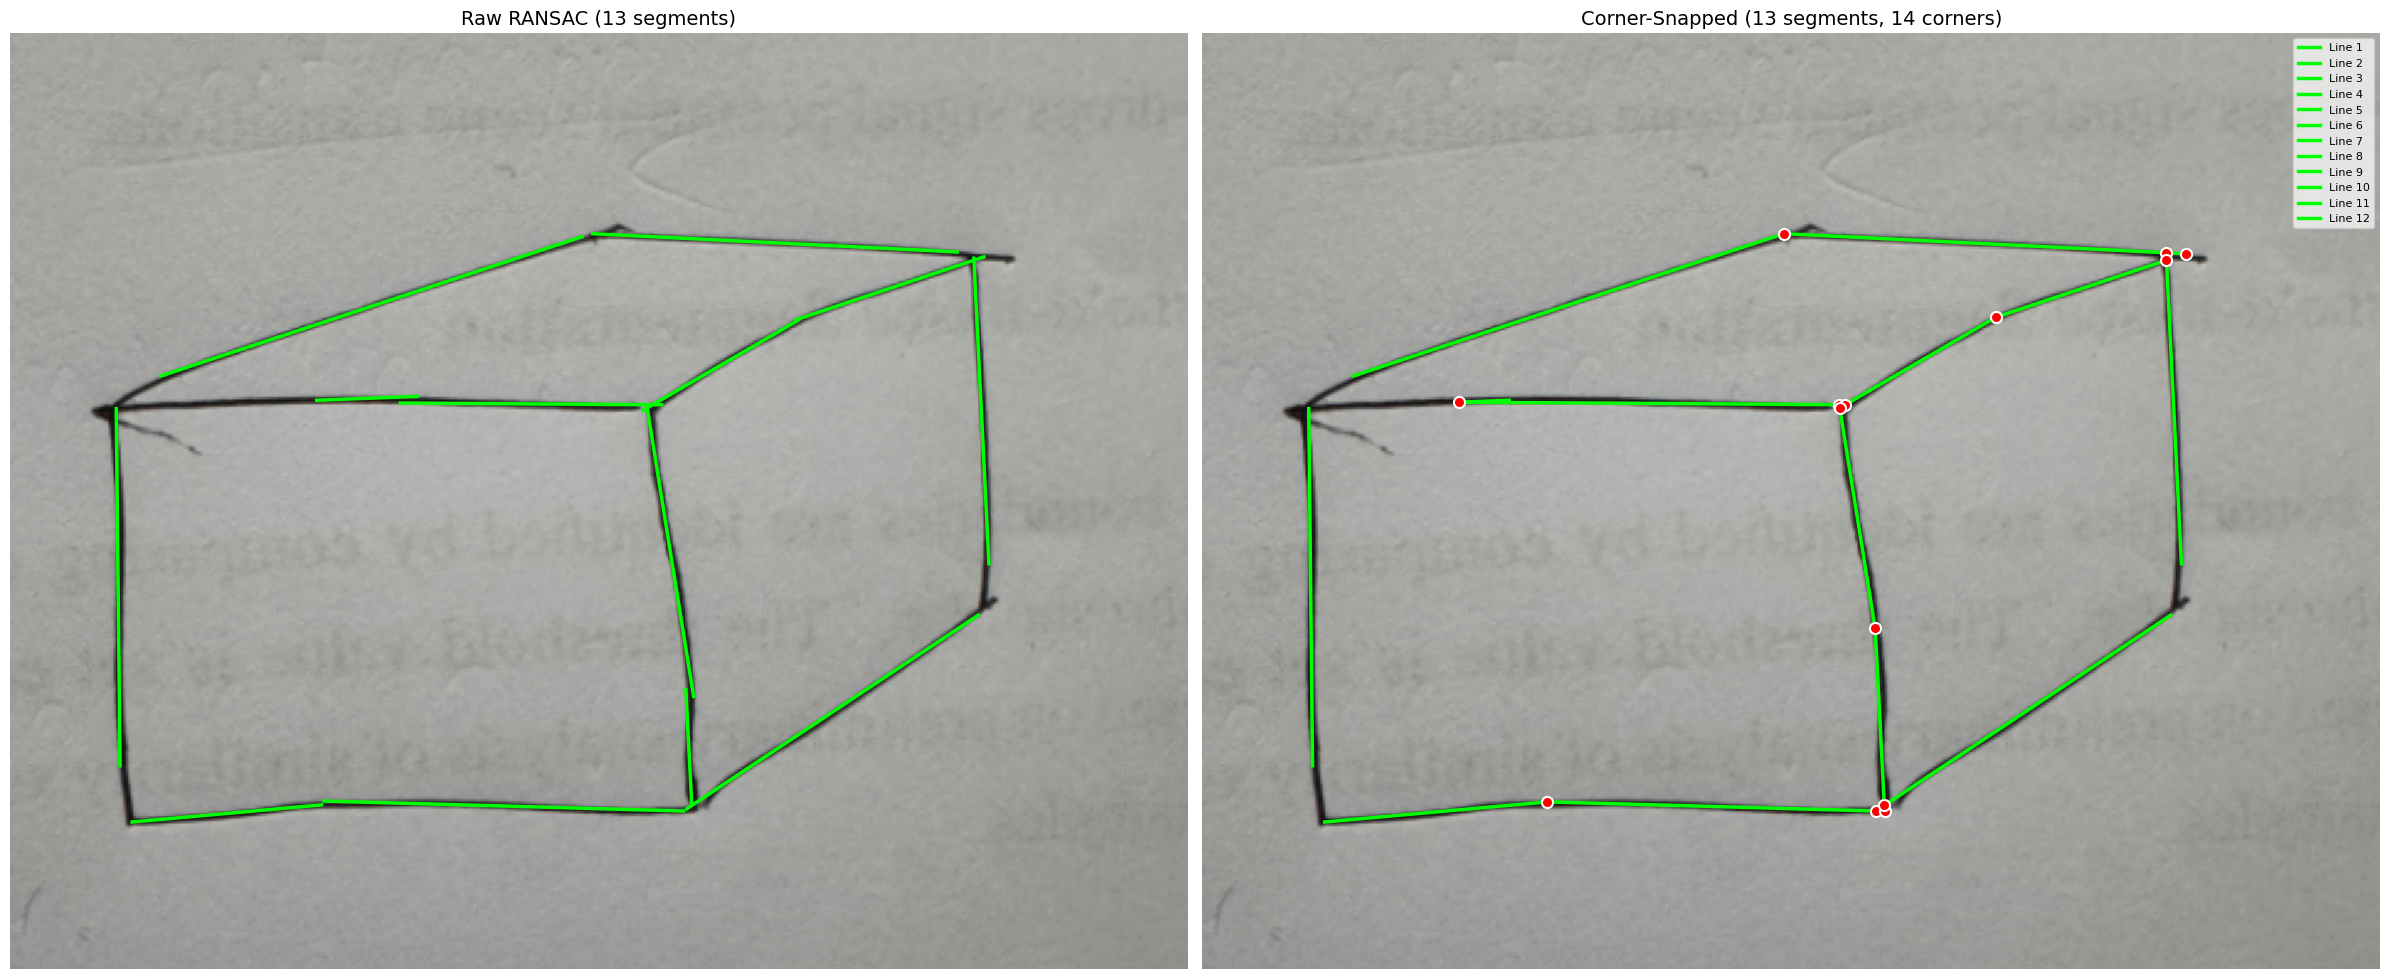

In [37]:
# Cell 5: Visualization

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# --- Left: Raw RANSAC lines ---
axes[0].imshow(img_rgb)
axes[0].set_title(f'Raw RANSAC ({len(detected_lines)} segments)', fontsize=14)
axes[0].axis('off')
for idx, (x0, y0, x1, y1) in enumerate(detected_lines):
    axes[0].plot([x0, x1], [y0, y1], color='lime', linewidth=2.5)

# --- Right: Corner-snapped lines ---
axes[1].imshow(img_rgb)
axes[1].set_title(f'Corner-Snapped ({len(snapped_lines)} segments, {len(snapped_corners)} corners)', fontsize=14)
axes[1].axis('off')
for idx, (x0, y0, x1, y1) in enumerate(snapped_lines):
    axes[1].plot([x0, x1], [y0, y1], color='lime', linewidth=2.5,
                 label=f'Line {idx+1}' if idx < 12 else None)

# Draw small circles at snapped corner joints
for cx, cy in snapped_corners:
    axes[1].plot(cx, cy, 'ro', markersize=8, markeredgecolor='white', markeredgewidth=1.5)

axes[1].legend(loc='upper right', fontsize=8, framealpha=0.7)

plt.tight_layout()
plt.show()

# === TUNING TIPS ===
# 1. snap_threshold (Cell 4):
#    - Increase to snap corners that are farther apart.
#    - Decrease if false snaps are occurring between unrelated lines.
#
# 2. RANSAC residual_threshold (Cell 3):
#    - For 1-pixel skeletons, keep at 1.0-1.5.
#
# 3. max_gap (Cell 3):
#    - Controls how aggressively line segments are trimmed at gaps.
#
# 4. Adaptive threshold params (Cell 1: adaptive_block, adaptive_C):
#    - Increase adaptive_C to require darker strokes.
#    - Increase adaptive_block for broader local context.